# Online vs In-Store Shopping Behaviour Analysis

## Project Objective
Predict whether a consumer prefers:
- Online shopping
- Physical retail stores
- Hybrid shopping

### Importing libraries

In [46]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

import warnings

In [49]:
# Ignore warning message for better readability
warnings.filterwarnings('ignore')

### Load dataset and Data Cleaning

In [5]:
data = pd.read_csv('online vs store shopping dataset.csv')
data.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_days          

In [7]:
data.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [12]:
data.isnull().sum()

age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64

In [11]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
11784    False
11785    False
11786    False
11787    False
11788    False
Length: 11789, dtype: bool

### Exploratory Data Analysis

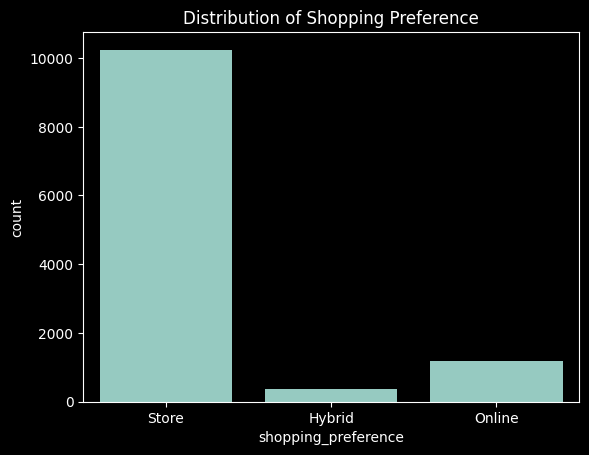

In [16]:
sns.countplot(data=data, x="shopping_preference")
plt.title("Distribution of Shopping Preference")
plt.show()

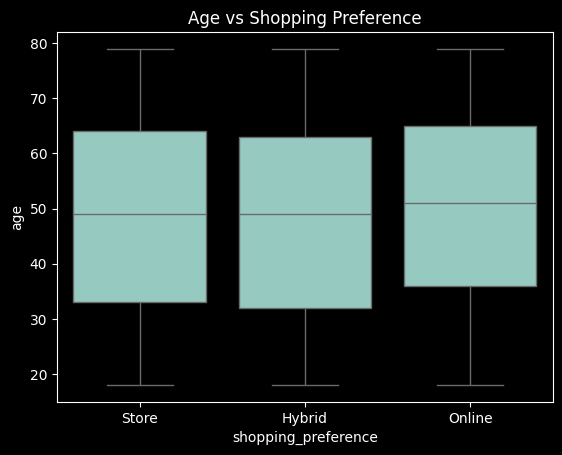

In [17]:
sns.boxplot(data=data, x="shopping_preference", y="age")
plt.title("Age vs Shopping Preference")
plt.show()

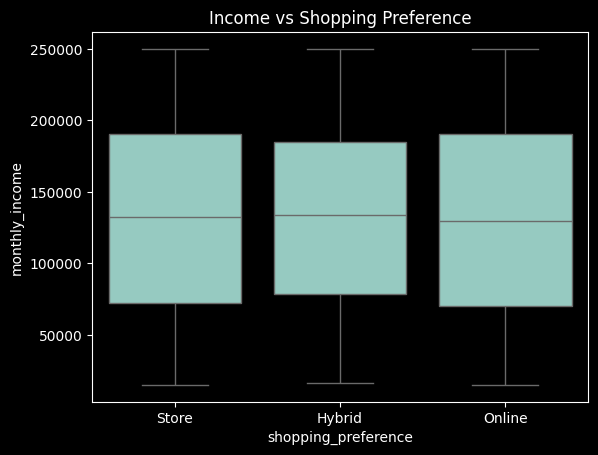

In [18]:
sns.boxplot(data=data, x="shopping_preference", y="monthly_income")
plt.title("Income vs Shopping Preference")
plt.show()

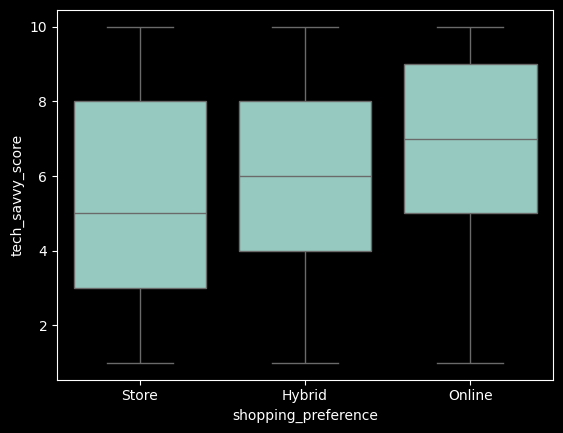

In [19]:
sns.boxplot(data=data, x="shopping_preference", y="tech_savvy_score")
plt.show()

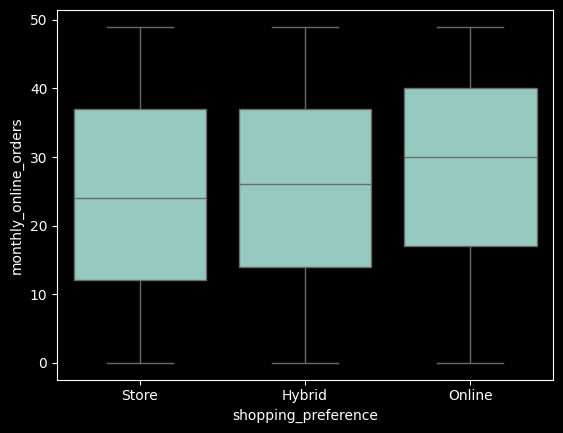

In [21]:
sns.boxplot(data=data, x="shopping_preference", y="monthly_online_orders")
plt.show()

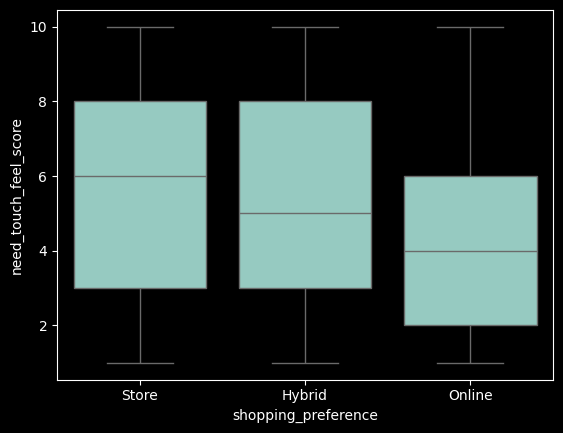

In [22]:
sns.boxplot(data=data, x="shopping_preference", y="need_touch_feel_score")
plt.show()

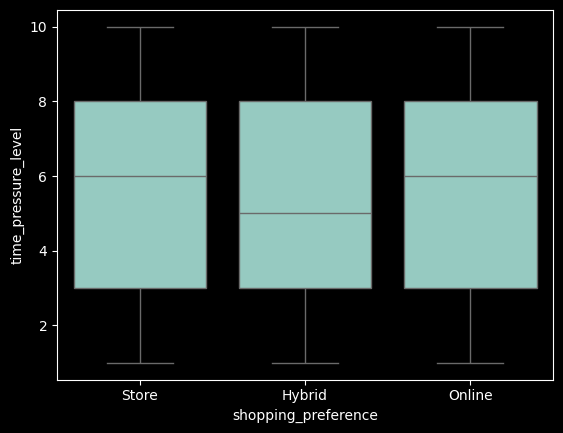

In [24]:
sns.boxplot(data=data, x="shopping_preference", y="time_pressure_level")
plt.show()

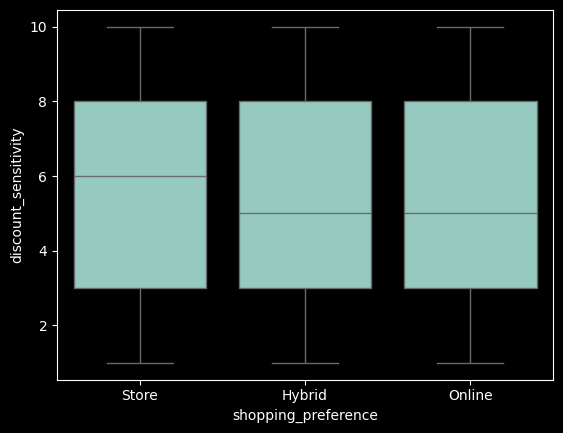

In [62]:
sns.boxplot(data=data, x="shopping_preference", y="discount_sensitivity")
plt.show()

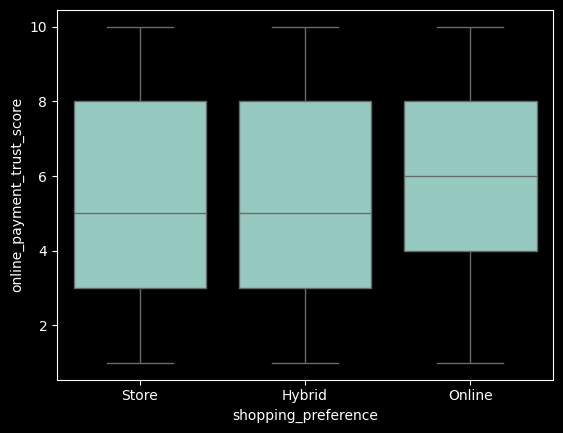

In [71]:
sns.boxplot(data=data, x="shopping_preference", y="online_payment_trust_score")
plt.show()

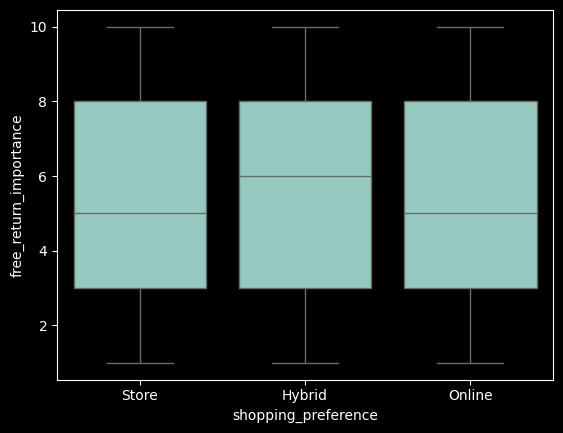

In [73]:
sns.boxplot(data=data, x="shopping_preference", y="free_return_importance")
plt.show()

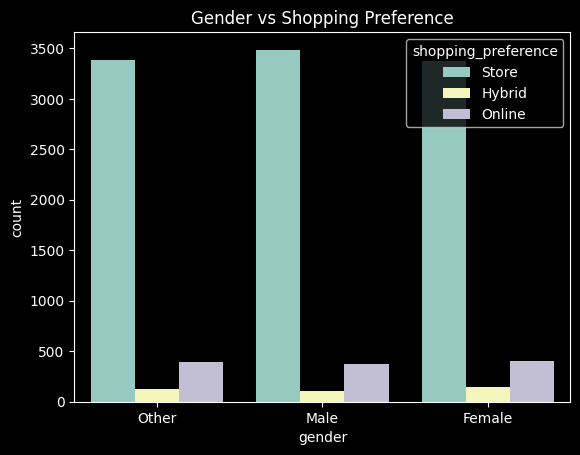

In [25]:
sns.countplot(data=data, x="gender", hue="shopping_preference")
plt.title("Gender vs Shopping Preference")
plt.show()

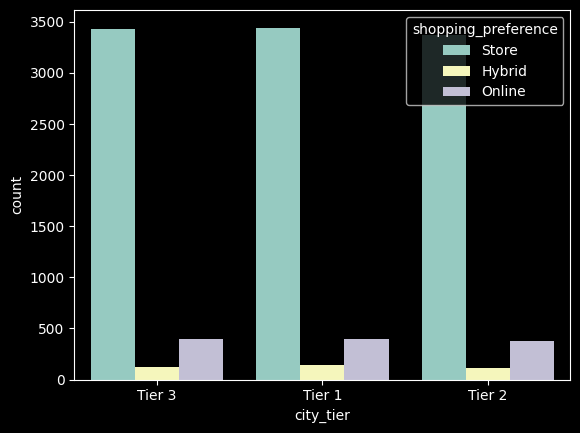

In [26]:
sns.countplot(data=data, x="city_tier", hue="shopping_preference")
plt.show()

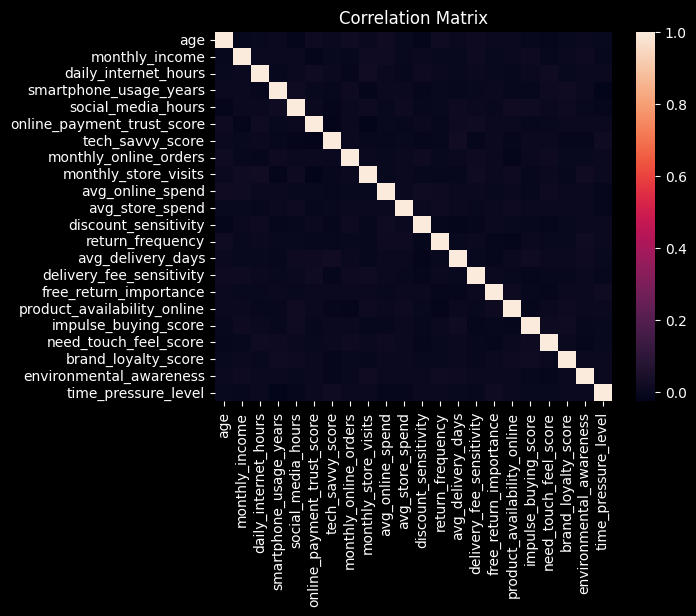

In [33]:
corr = data.select_dtypes('number').corr()
sns.heatmap(corr)
plt.title('Correlation Matrix')
plt.show()

### Data Cleaning - Remove outliers

In [34]:
numeric_cols = data.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower, lower, data[col])
    data[col] = np.where(data[col] > upper, upper, data[col])

### Feature Engineering and Processing

In [40]:
X = data.drop("shopping_preference", axis=1)
y = data["shopping_preference"]

categorical_cols = ["gender", "city_tier"]
numeric_cols = X.select_dtypes(include=np.number).columns

numeric_pipeline = Pipeline([
    ("power", PowerTransformer()),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

pca = PCA(n_components=0.95, random_state=35)

### Model Building

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=35
)

# Model Evaluation
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"\nModel: {name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return acc, f1


Model: Logistic Regression
Accuracy: 0.9821882951653944
F1 Score: 0.9800309971501985

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.86      0.51      0.64        74
      Online       0.94      0.99      0.96       235
       Store       0.99      1.00      0.99      2049

    accuracy                           0.98      2358
   macro avg       0.93      0.83      0.87      2358
weighted avg       0.98      0.98      0.98      2358



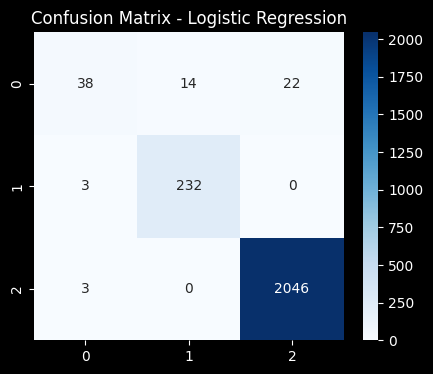

In [44]:
# Logistic Regression

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", pca),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_acc, log_f1 = evaluate_model(log_model, X_test, y_test, "Logistic Regression")


Model: Random Forest
Accuracy: 0.9508057675996607
F1 Score: 0.9355272102669785

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.00      0.00      0.00        74
      Online       0.87      0.88      0.87       235
       Store       0.96      0.99      0.98      2049

    accuracy                           0.95      2358
   macro avg       0.61      0.62      0.62      2358
weighted avg       0.92      0.95      0.94      2358



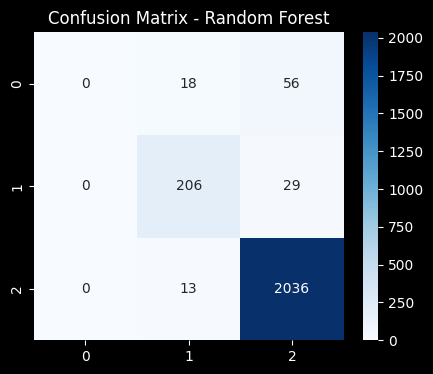

In [58]:
# Random Forest Model

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=35, n_jobs=-1))
])

rf_model.fit(X_train, y_train)

rf_acc, rf_f1 = evaluate_model(rf_model, X_test, y_test, "Random Forest")




Model: Gradient Boosting
Accuracy: 0.9168787107718406
F1 Score: 0.896360069384099

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.50      0.01      0.03        74
      Online       0.88      0.51      0.65       235
       Store       0.92      1.00      0.96      2049

    accuracy                           0.92      2358
   macro avg       0.77      0.51      0.54      2358
weighted avg       0.90      0.92      0.90      2358



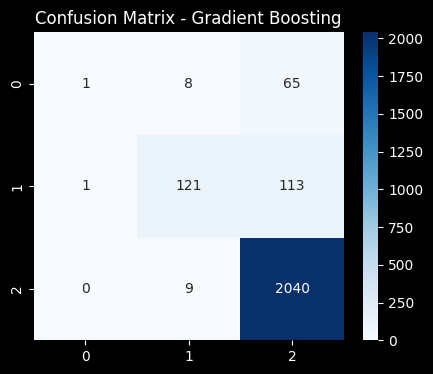

In [51]:
# Gradient Boosting

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", pca),
    ("classifier", GradientBoostingClassifier())
])

gb_model.fit(X_train, y_train)

gb_acc, gb_f1 = evaluate_model(gb_model, X_test, y_test, "Gradient Boosting")

### Model Comparison

In [53]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [log_acc, rf_acc, gb_acc],
    "F1 Score": [log_f1, rf_f1, gb_f1]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,F1 Score
0,Logistic Regression,0.982188,0.980031
2,Gradient Boosting,0.916879,0.896360
1,Random Forest,0.891858,0.855296


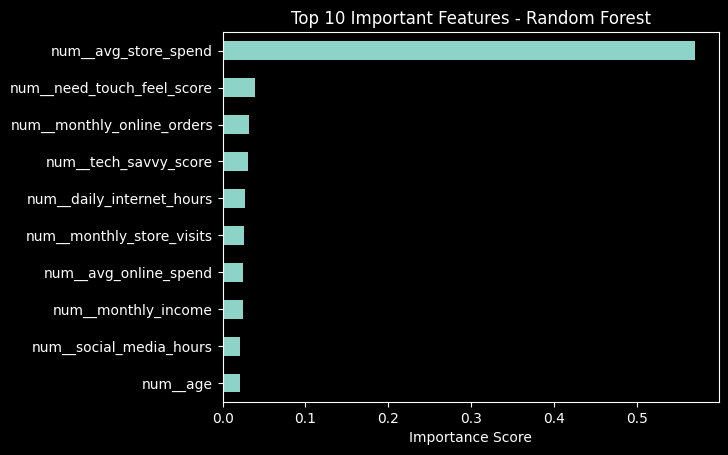

In [60]:
# Feature importance from Random Forest Model
rf_classifier = rf_model.named_steps["classifier"]
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importance = rf_classifier.feature_importances_

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

feat_imp.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.show()

# Conclusion and Recommendations

Best Model: Logistic Regression

Insights:

1. Age and income do not affect shopping behaviour
2. Tech leaning customers prefer online purchasing
3. Customer who needs to feel the merchandise prefer in-store shopping
4. Customer who trust online payment tend to use online shopping
4. More time spent online means higher chance of purchasing online
5. High impulse buyers lean hybrid, they purchase whenever they feel the urge

Business Recommendation:

- Targeted advertisement with promotions on online and tech-savvy users
- Provide and improve in-store experience for high touch feel need customers
- Provide free returns to convert hybrid customers into online customers